<center><h1>Weiwen Li_HW1</h1></center>
<br>
<center><font size="4">K-Nearest Neighbor Classification on Vertebral Column Data</font></center>

### (a) Download Data

#### Package Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, f1_score

#### Load the Vertebral Column Data Set

Download the data from [https://archive.ics.uci.edu/ml/datasets/Vertebral+Column](https://archive.ics.uci.edu/ml/datasets/Vertebral+Column). The dataset contains six biomechanical features (pelvic incidence, pelvic tilt, lumbar lordosis angle, sacral slope, pelvic radius, grade of spondylolisthesis) and a class label.

Use the **binary classification** file (`column_2C.dat`) with class labels `AB` (Abnormal = 1) and `NO` (Normal = 0).

In [2]:
columns = ['pelvic_incidence', 'pelvic_tilt', 'lumbar_lordosis_angle',
           'sacral_slope', 'pelvic_radius', 'degree_spondylolisthesis', 'class']
df = pd.read_csv('../../Homework 1 Data/vertebral_column_data/column_2C.dat',
                 sep=r'\s+', header=None, names=columns)
df['class'] = df['class'].map({'NO': 0, 'AB': 1})
features = columns[:-1]
print(df.shape, df['class'].value_counts().to_dict())
df.head()

(310, 7) {1: 210, 0: 100}


,pelvic_incidence,pelvic_tilt,lumbar_lordosis_angle,sacral_slope,pelvic_radius,degree_spondylolisthesis,class
0,63.03,22.55,39.61,40.48,98.67,-0.25,1
1,39.06,10.06,25.02,29.00,114.41,4.56,1
2,68.83,22.22,50.09,46.61,105.99,-3.53,1
3,69.30,24.65,44.31,44.64,101.87,11.21,1
4,49.71,9.65,28.32,40.06,108.17,7.92,1


### (b) Pre-Processing and Exploratory Data Analysis

#### i. Scatterplots

Make scatterplots of the independent variables in the dataset. Use color to differentiate Class 0 (Normal) and Class 1 (Abnormal).

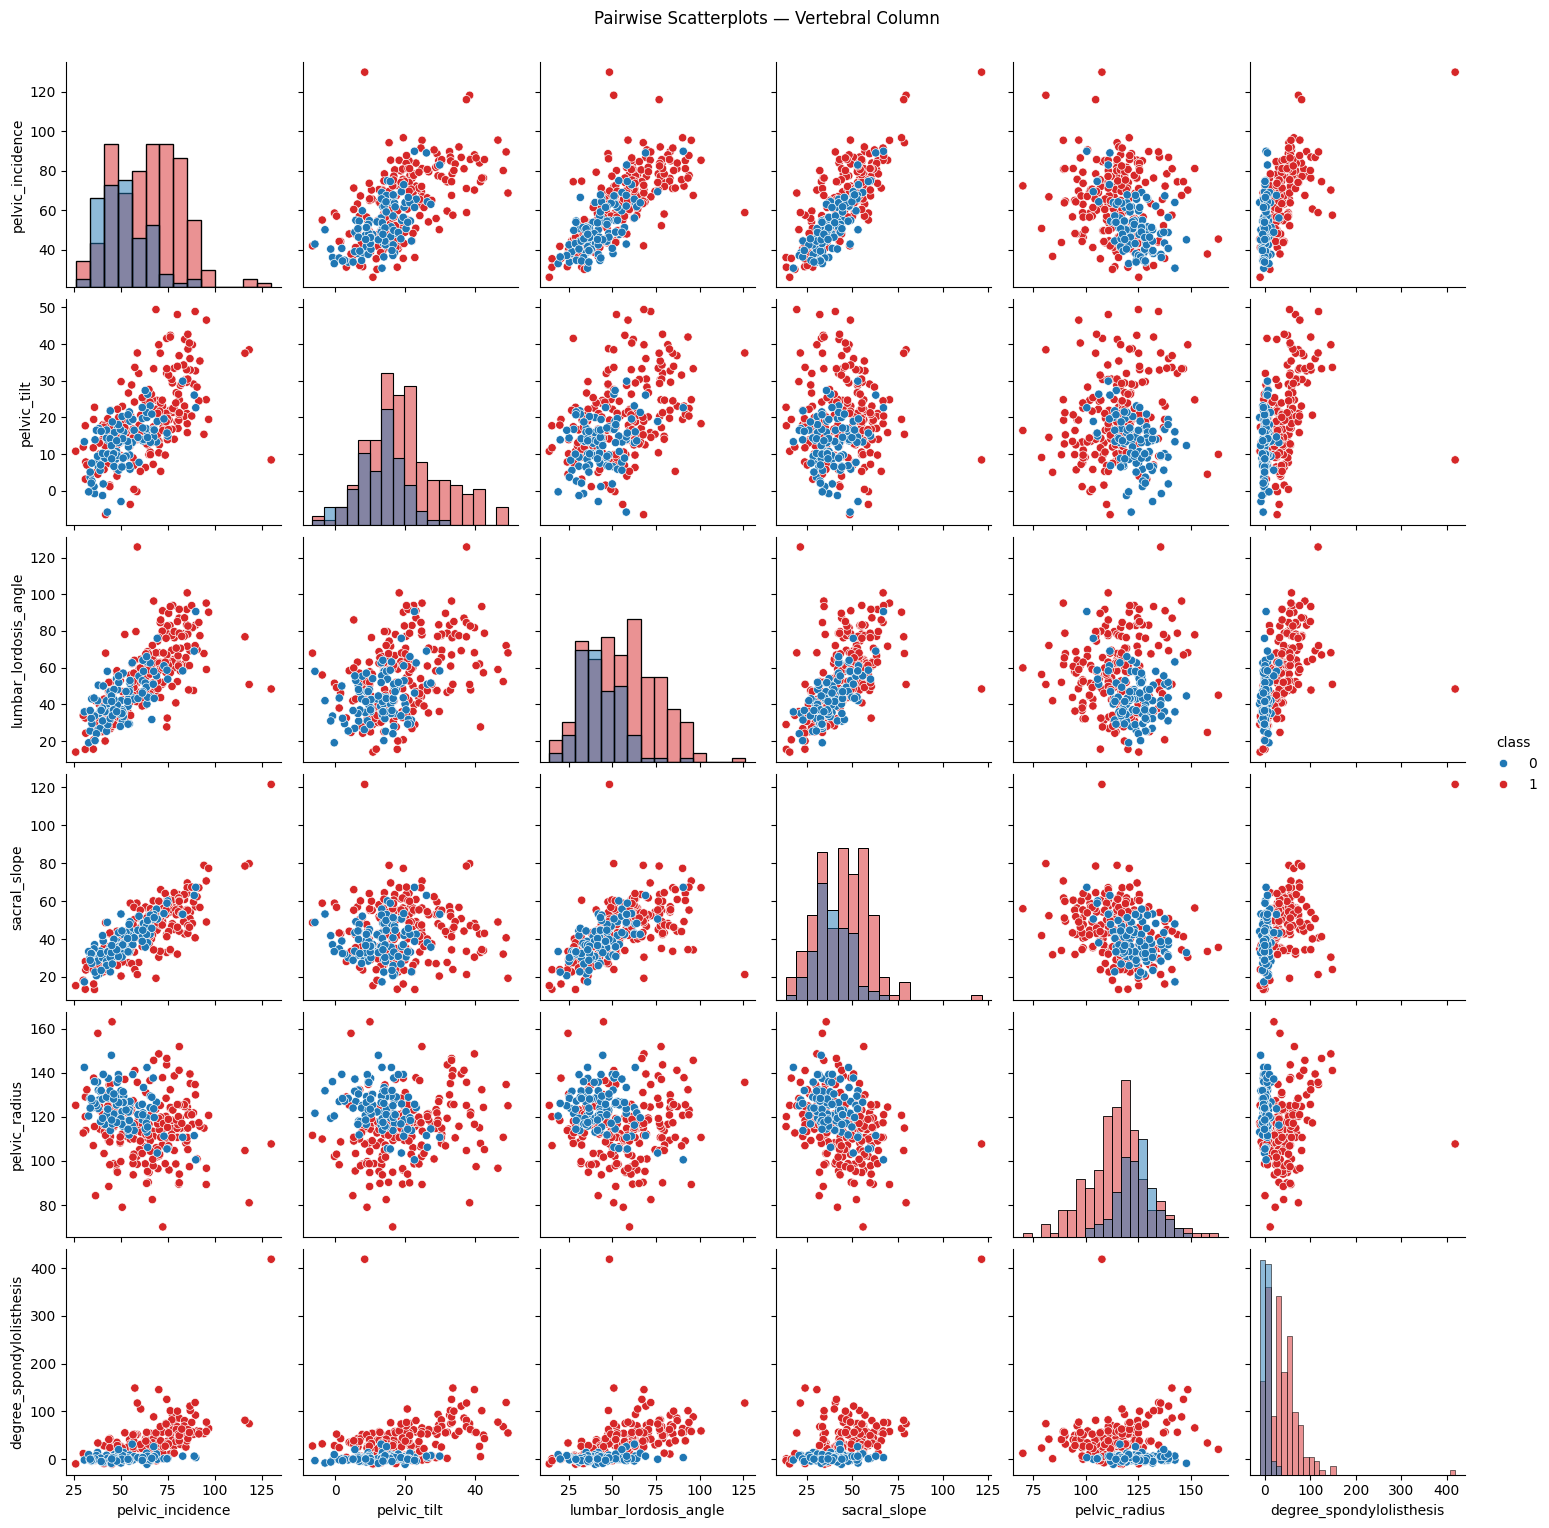

In [3]:
sns.pairplot(df, hue='class', diag_kind='hist',
             palette={0: 'tab:blue', 1: 'tab:red'})
plt.suptitle('Pairwise Scatterplots — Vertebral Column', y=1.02)
plt.show()

#### ii. Boxplots

Make boxplots for each of the independent variables in the dataset. Use color to show Classes 0 and 1 (see ISLR p. 129).

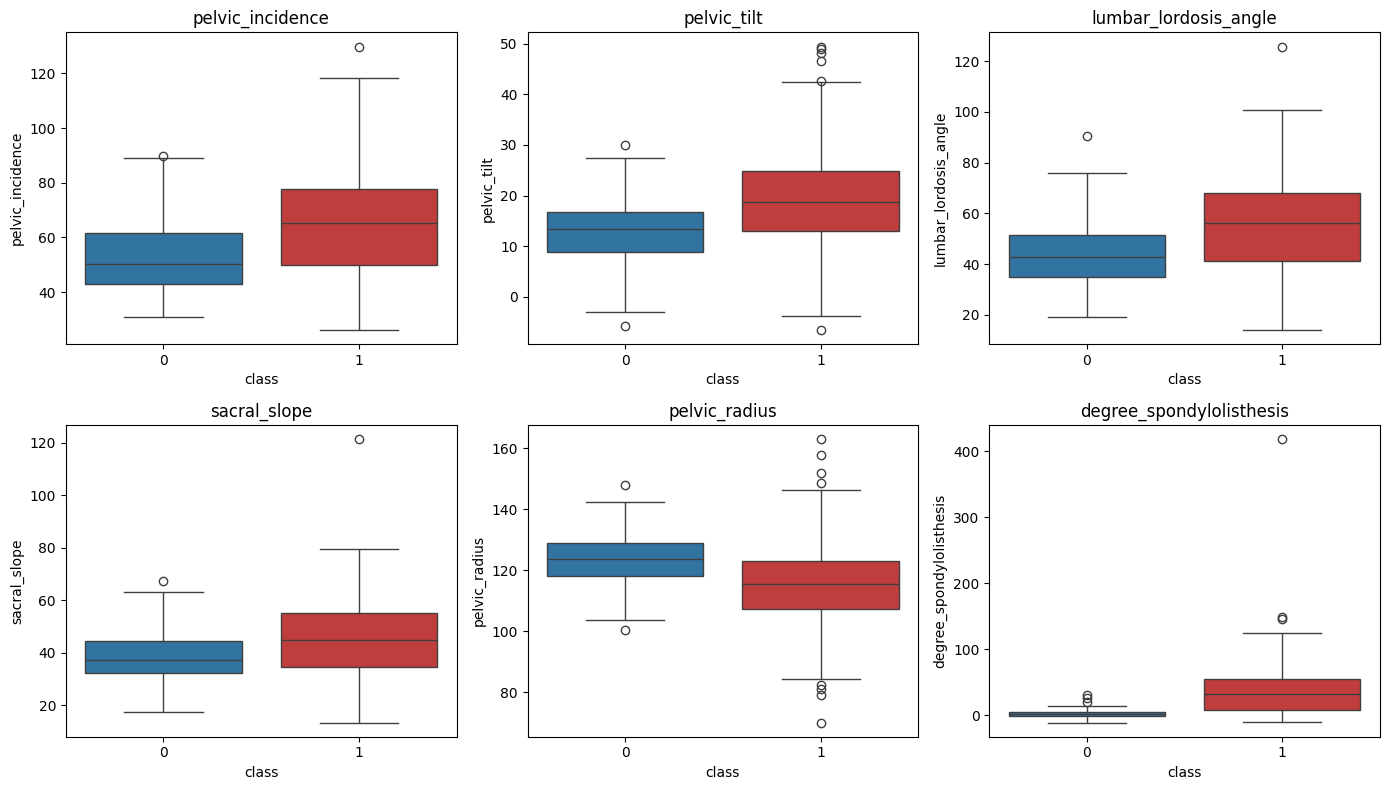

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for ax, feat in zip(axes.flat, features):
    sns.boxplot(data=df, x='class', y=feat, hue='class', ax=ax,
                palette={0: 'tab:blue', 1: 'tab:red'}, legend=False)
    ax.set_title(feat)
plt.tight_layout(); plt.show()


#### iii. Split Data Set

Select the first **70 rows of Class 0** and the first **140 rows of Class 1** as the training set. Use the rest of the data as the test set.

In [6]:
class0 = df[df['class'] == 0]
class1 = df[df['class'] == 1]
train = pd.concat([class0.iloc[:70],  class1.iloc[:140]])
test  = pd.concat([class0.iloc[70:],  class1.iloc[140:]])
X_train, y_train = train[features].values, train['class'].values
X_test,  y_test  = test[features].values,  test['class'].values
print('Train:', X_train.shape, 'Test:', X_test.shape)

Train: (210, 6) Test: (100, 6)


### (c) Classification using KNN with Euclidean Metric

#### i. Euclidean Metric

Write code for k-nearest neighbors with Euclidean metric (or use a software package such as `sklearn.neighbors.KNeighborsClassifier`). Decisions are made by **majority polling**.

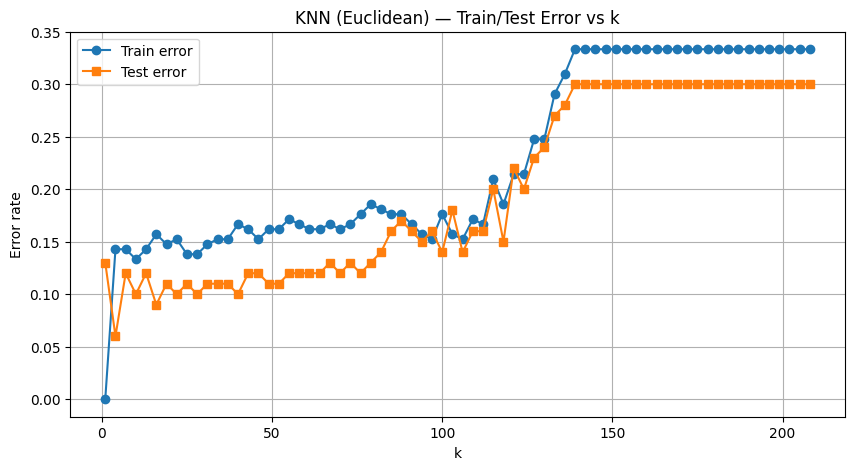

k* = 4, test error = 0.0600


In [7]:
k_values = list(range(1, 209, 3))        # 1, 4, 7, ..., 208
train_errs, test_errs = [], []
for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k, metric='euclidean')
    knn.fit(X_train, y_train)
    train_errs.append(1 - knn.score(X_train, y_train))
    test_errs.append (1 - knn.score(X_test,  y_test))

plt.figure(figsize=(10, 5))
plt.plot(k_values, train_errs, 'o-', label='Train error')
plt.plot(k_values, test_errs,  's-', label='Test error')
plt.xlabel('k'); plt.ylabel('Error rate')
plt.title('KNN (Euclidean) — Train/Test Error vs k')
plt.legend(); plt.grid(True); plt.show()
best_k = k_values[int(np.argmin(test_errs))]
print(f'k* = {best_k}, test error = {min(test_errs):.4f}')

#### ii. Test Data — Error Rates vs. k

Test all the data in the test database with k nearest neighbors (majority polling). Plot **train and test errors** as a function of k. Among the tested k values, identify the best k* (the most suitable k).

For k*, compute and display:
- Confusion matrix
- True Positive Rate (TPR)
- True Negative Rate (TNR)
- Precision
- F₁-score

In [8]:
knn = KNeighborsClassifier(n_neighbors=best_k, metric='euclidean').fit(X_train, y_train)
y_pred = knn.predict(X_test)
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
print(f'Confusion matrix:\n[[TN={tn}, FP={fp}],\n [FN={fn}, TP={tp}]]')
print(f'TPR (recall) = {tp/(tp+fn):.4f}')
print(f'TNR          = {tn/(tn+fp):.4f}')
print(f'Precision    = {tp/(tp+fp):.4f}')
print(f'F1 score     = {f1_score(y_test, y_pred):.4f}')

Confusion matrix:
[[TN=25, FP=5],
 [FN=1, TP=69]]
TPR (recall) = 0.9857
TNR          = 0.8333
Precision    = 0.9324
F1 score     = 0.9583


#### iii. Learning Curve

Study how computation time and test error depend on the **size of the training set**.

For each training set size N ∈ {10, 20, 30, …} (incrementing by 10 or another step):
- Build the training set by selecting the first ⌊N/2⌋ rows of Class 0 and the first N − ⌊N/2⌋ rows of Class 1.
- For each N, select the optimal k from {1, 6, 11, …, N} (starting at k = 1, step = 5).
- Record the test error rate at the chosen optimal k.

Plot the test error rate against N. This plot is called the **Learning Curve**.

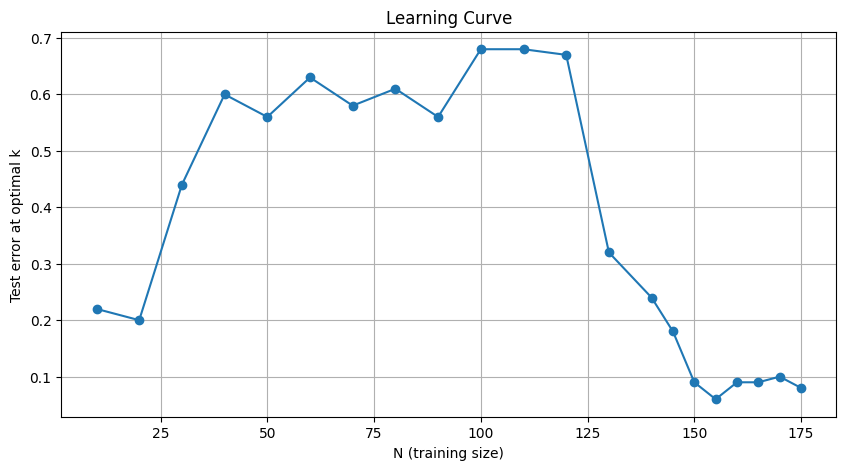

In [10]:
class0_train = class0.iloc[:70]    # 70 行训练集 class 0
class1_train = class1.iloc[:140]   # 140 行训练集 class 1

N_values = list(range(10, 211, 10))
curve = []
for N in N_values:
    half = N // 2
    n0 = min(half,         len(class0_train))   # cap 在 70
    n1 = min(N - half,     len(class1_train))   # cap 在 140
    X_sub = np.vstack([class0_train[features].iloc[:n0].values,
                       class1_train[features].iloc[:n1].values])
    y_sub = np.hstack([np.zeros(n0), np.ones(n1)])
    actual_N = n0 + n1

    k_set = [k for k in range(1, 197, 5) if k <= actual_N]
    errs = [1 - KNeighborsClassifier(n_neighbors=k, metric='euclidean')
                  .fit(X_sub, y_sub).score(X_test, y_test) for k in k_set]
    curve.append((actual_N, k_set[int(np.argmin(errs))], min(errs)))

Ns, ks, errs = zip(*curve)
plt.figure(figsize=(10, 5))
plt.plot(Ns, errs, 'o-')
plt.xlabel('N (training size)'); plt.ylabel('Test error at optimal k')
plt.title('Learning Curve'); plt.grid(True); plt.show()


### (d) Other Distance Metrics

Replace the Euclidean metric with the metrics below and test them. Summarize the test errors (at k = k* found in part c) in a table.

#### i. Minkowski Distance

In [11]:
k_set = list(range(1, 197, 5))

def sweep(metric, **kw):
    errs = [1 - KNeighborsClassifier(n_neighbors=k, metric=metric, **kw)
                .fit(X_train, y_train).score(X_test, y_test) for k in k_set]
    return errs, k_set[int(np.argmin(errs))], min(errs)


##### A. Manhattan Distance (p = 1)

Use the Minkowski distance with p = 1 (Manhattan distance). Report the test error rate.

In [12]:
errs_man, k_man, e_man = sweep('manhattan')
print(f'Manhattan: best k={k_man}, error={e_man:.4f}')

Manhattan: best k=6, error=0.1100


##### B. Minkowski Distance — Sweep log₁₀(p) ∈ {0.1, 0.2, …, 1}

Use the k* found in part (c). For each value of log₁₀(p) in {0.1, 0.2, 0.3, …, 1.0}, compute and plot the test error rate. Report the best log₁₀(p).

In [13]:
log_ps = np.arange(0.1, 1.01, 0.1)
mink_errs = []
for lp in log_ps:
    p = 10 ** lp
    e = 1 - KNeighborsClassifier(n_neighbors=k_man, metric='minkowski', p=p
                                 ).fit(X_train, y_train).score(X_test, y_test)
    mink_errs.append(e)
    print(f'log10(p)={lp:.1f}, p={p:.3f}, error={e:.4f}')
best_lp = log_ps[int(np.argmin(mink_errs))]
print(f'Best log10(p) = {best_lp:.1f}, error = {min(mink_errs):.4f}')

log10(p)=0.1, p=1.259, error=0.0900
log10(p)=0.2, p=1.585, error=0.0900
log10(p)=0.3, p=1.995, error=0.0800
log10(p)=0.4, p=2.512, error=0.0800
log10(p)=0.5, p=3.162, error=0.0800
log10(p)=0.6, p=3.981, error=0.0600
log10(p)=0.7, p=5.012, error=0.0700
log10(p)=0.8, p=6.310, error=0.0800
log10(p)=0.9, p=7.943, error=0.0900
log10(p)=1.0, p=10.000, error=0.0900
Best log10(p) = 0.6, error = 0.0600


##### C. Chebyshev Distance (p → ∞)

Use the Chebyshev distance (limit of Minkowski as p → ∞). Report the test error rate.

#### ii. Mahalanobis Distance

Use the Mahalanobis distance. Note: if the covariance matrix is singular or ill-conditioned, the data lives in a linear subspace of the feature space; in this case, transform the features to a reduced feature set in the linear subspace (equivalent to using a pseudoinverse). Report the test error rate.

### (e) Weighted Decision

The majority polling decision rule can be replaced by **weighted voting**, where each neighbor's vote is weighted inversely proportional to its distance from the query point (closer neighbors have more influence).

Apply weighted voting with Euclidean, Manhattan, and Chebyshev distances. For each metric, sweep k ∈ {1, 6, 11, …, 196} and report the best test error rate.

### (f) Training Error Rate

What is the **lowest training error rate** you achieved in this homework? Report the configuration (metric, k, weighting) that produced it.